In [1]:
# speed_kmh 주행속도,
# payload_kg,탑승자 및 화물 하중
# ambient_temp_C,외부 기온
# hvac_power_kw,냉난방 사용 전력
# road_grade_pct, 도로 경사도
# battery_temp_C,배터리 온도
# driving_style_index,
# tire_pressure_bar,겨울철 기온 강하로 인한 타이어 공기압 저하 영향
# trip_distance_km, 주행거리(도착지까지의 총 잔여 필요 전력 계산에 사용)

 # < 타겟변수 >
# energy_consumption_kwhper100km (타깃 변수 : 100km당 소비 전력량) 

In [2]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

import platform
from matplotlib import rc


if platform.system() == 'MacOS':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('MacOS system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False


Unknown system... sorry~~~~


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [4]:
df = pd.read_csv('data/ev_energy_consumption.csv')
df

,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883
...,...,...,...,...,...,...,...,...,...,...
7995,50.0,3.8,35.7,2.79,4.80,32.3,0.986,2.11,172.4,23.931
7996,43.0,286.3,11.4,4.20,4.94,17.3,0.643,2.54,130.4,26.811
7997,70.1,358.6,8.9,3.81,-1.50,30.5,0.709,2.16,166.6,26.102
7998,119.9,372.5,1.6,0.59,0.65,17.6,0.757,2.28,172.8,28.355


In [5]:
# 데이터 구조 결측치 확인
df.shape

(8000, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [7]:
# 결측치 확인
df.isna().sum()

speed_kmh                         0
payload_kg                        0
ambient_temp_C                    0
hvac_power_kw                     0
road_grade_pct                    0
battery_temp_C                    0
driving_style_index               0
tire_pressure_bar                 0
trip_distance_km                  0
energy_consumption_kwhper100km    0
dtype: int64


=== 핵심 제어 인자와 전비 간의 상관계수 ===
road_grade_pct    0.504623
payload_kg        0.468906
speed_kmh         0.448316
hvac_power_kw     0.369619
Name: energy_consumption_kwhper100km, dtype: float64


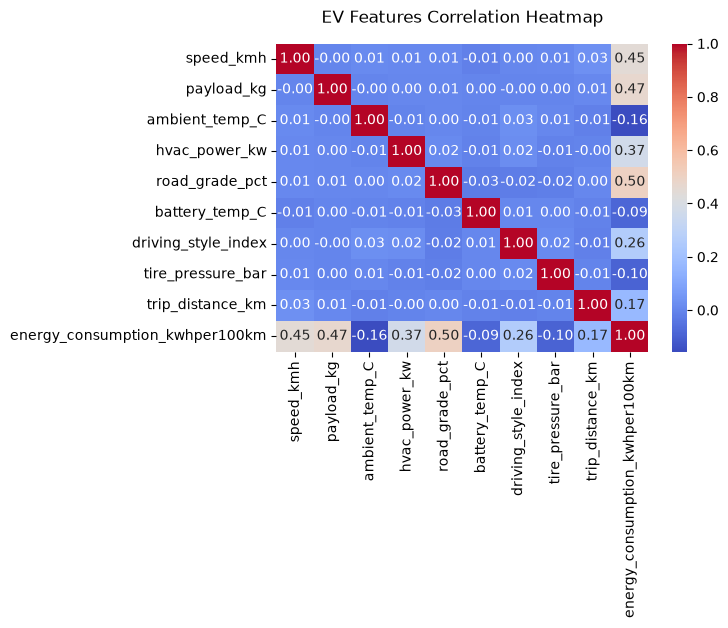

In [8]:
# 상관계수 행렬 연산
corr_matrix = df.corr()

# 주요 4대 영향 인자의 전비 상관계수 별도 출력
target_col = 'energy_consumption_kwhper100km'

key_features = ['speed_kmh', 'payload_kg', 'road_grade_pct', 'hvac_power_kw']
print("\n=== 핵심 제어 인자와 전비 간의 상관계수 ===")
print(corr_matrix[target_col][key_features].sort_values(ascending=False)) #[cite: 2]

# 상관관계 히트맵 시각화
plt.figure(figsize=(6, 4))
sb.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True
) 

plt.title('EV Features Correlation Heatmap', pad=15)
plt.show()

## 데이터 분할


In [9]:
# 1. 특성(X)과 타깃(y) 분리
X = df.drop(['energy_consumption_kwhper100km'], axis =1)

In [10]:
X.shape

(8000, 9)

In [11]:
# 100km당 전비 (연속형 수치)
y = df['energy_consumption_kwhper100km']   

In [12]:
y.shape

(8000,)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


feature들이 모두 수치형 데이터이고, 결측치도 없기 때문에 scaling이 필요하지 않다.

In [14]:
from sklearn.model_selection import train_test_split

# X_train, y_train : 회귀모델이 가중치를 학습하는 훈련용 데이터
# X_test, y_test : 학습된 회귀모델이 예측 성능을 검증하는 테스트용 데이터

# 2. 학습용(Train)과 검증용(Test) 데이터 분할 (8:2)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 전체 8,000개 중 20%(1,600개)를 테스트용으로 분할
    random_state=42      # 언제 실행해도 동일하게 나뉘도록 난수 시드 고정
)

In [15]:
print(f"학습용 X: {X_train.shape}, 학습용 y: {y_train.shape}")
print(f"검증용 X: {X_test.shape},  검증용 y: {y_test.shape}")

학습용 X: (6400, 9), 학습용 y: (6400,)
검증용 X: (1600, 9),  검증용 y: (1600,)


- 전비 예측 엔진 확보 : 추천 엔진의 핵심인 알파 가중치 목적 함수를 계산하려면 속도와 외생조건에 따른 전력 소비량을 산출해줄 신뢰할 수 있는 회귀모델이 먼저 완성되어야 함.

- 선형회귀의 회귀계수(coef)와 트리의 피처 중요도를 통해 속도/경사도/공조 등이 전치에 미치는 실제 물리적 영향력을 수치로 증명할 수 있다.

- 추천 오차 최소화 :  여러 알고리즘을 개별 평가하여 가장 예측 오차가 작고 일반화 성능이 우수한 최종 모델 선정

### LinearRegression

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. 선형 회귀 모델 생성
lr_reg = LinearRegression()

# 학습
lr_reg.fit(X_train, y_train)

# 예측
lr_test_pred = lr_reg.predict(X_test)

print("=== [1. Linear Regression 성능 평가] ===")
print(f"R² Score  : {r2_score(y_test, lr_test_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, lr_test_pred)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, lr_test_pred):.4f} ")


=== [1. Linear Regression 성능 평가] ===
R² Score  : 0.9246
RMSE      : 1.0093
MAE       : 0.8107 


### LGBMRegressor
- 기본 성능이 LightGBM은 기본 설정(n_estimators=100, learning_rate=0.1, num_leaves=31 등) 자체가 매우 균형 있게 잡혀 있어, 튜닝 전에도 높은 예측력을 보여주기 때문에 튜닝 생략 ..

In [17]:
from lightgbm import LGBMRegressor

# 1. LightGBM 회귀 모델 생성 및 학습
lgb_reg = LGBMRegressor()
lgb_reg.fit(X_train, y_train)

# 2. 예측 수행
lgb_train_pred = lgb_reg.predict(X_train)
lgb_test_pred = lgb_reg.predict(X_test)

# 3. 성능 평가 지표 출력
print("=== [4. LightGBM Regressor 평가] ===")
print(f"R² Score  : {r2_score(y_test, lgb_test_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, lgb_test_pred)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, lgb_test_pred):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2091
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 9
[LightGBM] [Info] Start training from score 24.164264
=== [4. LightGBM Regressor 평가] ===
R² Score  : 0.9371
RMSE      : 0.9216
MAE       : 0.7337


#### RandomForest + RandomizedSearchCV 

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# 기본 모델 생성
rf_reg = RandomForestRegressor(
    random_state = 2024,
    n_jobs=-1
)

# RandomForest 하이퍼파라미터 탐색 공간
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.8, 1.0]
}

# Randomized Search 
rf_search = RandomizedSearchCV(
    estimator=rf_reg,
    param_distributions=rf_params,
    n_iter=30,  # 탐색할 하이퍼파라미터 조합 수
    scoring='neg_mean_squared_error',  # 평가 지표
    cv=5,  # 5-fold 교차 검증
    verbose=1,
    random_state=2024,
    n_jobs=-1
)

# 학습
rf_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터로 모델 재생성
rf_reg = rf_search.best_estimator_

# 평가
rf_pred = rf_reg.predict(X_test)

# 확인
print("=== [RandomForest 튜닝 결과] ===")
print("Best Params:", rf_search.best_params_)
print(f"R² Score : {r2_score(y_test, rf_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
=== [RandomForest 튜닝 결과] ===
Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
R² Score : 0.9020
MAE      : 0.9226
RMSE     : 1.1508


In [19]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(rf_importance)

               Feature  Importance
4       road_grade_pct    0.249969
1           payload_kg    0.221584
0            speed_kmh    0.196031
3        hvac_power_kw    0.129536
6  driving_style_index    0.076643
2       ambient_temp_C    0.054134
8     trip_distance_km    0.034282
7    tire_pressure_bar    0.019111
5       battery_temp_C    0.018711


In [29]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# 기본 모델 생성
xgb_reg = XGBRegressor(
    random_state = 2024,
    n_jobs=-1
)

# XGBRegressor 하이퍼파라미터 탐색 공간
xgb_params = {
    'n_estimators': [100, 200, 300],          # 트리 개수 (학습 반복 횟수)
    'max_depth': [3, 5, 7, 9],                 # 개별 트리의 최대 깊이
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # 이전 트리의 오차 반영 비율 (학습률)
    'subsample': [0.7, 0.8, 1.0],              # 매 트리 학습 시 데이터 샘플링 비율
    'colsample_bytree': [0.7, 0.8, 1.0]        # 매 트리 학습 시 피처(컬럼) 샘플링 비율
}

# Randomized Search 
xgb_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=xgb_params,
    n_iter=30,  # 탐색할 하이퍼파라미터 조합 수
    scoring='neg_mean_squared_error',  # 평가 지표
    cv=5,  # 5-fold 교차 검증
    verbose=1,
    random_state=2024,
    n_jobs=-1
)

# 학습
xgb_search.fit(X_train, y_train)

# 최적의 하이퍼파라미터로 모델 재생성
xgb_reg = xgb_search.best_estimator_

# 평가
xgb_pred = xgb_reg.predict(X_test)

# 확인
print("=== [XGBoost 튜닝 결과] ===")
print("Best Params:", xgb_search.best_params_)
print(f"R² Score : {r2_score(y_test, xgb_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, xgb_pred):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
=== [XGBoost 튜닝 결과] ===
Best Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
R² Score : 0.9449
MAE      : 0.6835
RMSE     : 0.8629


In [30]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_reg.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

print(xgb_importance)

               Feature  Importance
4       road_grade_pct    0.228418
1           payload_kg    0.222821
0            speed_kmh    0.193650
3        hvac_power_kw    0.139424
6  driving_style_index    0.093256
2       ambient_temp_C    0.059905
8     trip_distance_km    0.035101
7    tire_pressure_bar    0.016588
5       battery_temp_C    0.010837


In [31]:
# 4개 개별 모델 평가 결과 정리
eval_table = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'Test R²': r2_score(y_test, lr_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, lr_test_pred)),
        'Test MAE': mean_absolute_error(y_test, lr_test_pred)
    },
    {
        'Model': 'Random Forest',
        'Test R²': r2_score(y_test, rf_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
        'Test MAE': mean_absolute_error(y_test, rf_pred)
    },
    {
        'Model': 'XGBoost',
        'Test R²': r2_score(y_test, xgb_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
        'Test MAE': mean_absolute_error(y_test, xgb_pred)
    },
    {
        'Model': 'LightGBM',
        'Test R²': r2_score(y_test, lgb_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, lgb_test_pred)),
        'Test MAE': mean_absolute_error(y_test, lgb_test_pred)
    }
]).round(4)

print("=== [ 4개의 회귀 모델 성능 벤치마크 결과] ===")
display(eval_table.sort_values(by='Test R²', ascending=False))

=== [ 4개의 회귀 모델 성능 벤치마크 결과] ===


,Model,Test R²,Test RMSE,Test MAE
2,XGBoost,0.9449,0.8629,0.6835
3,LightGBM,0.9371,0.9216,0.7337
0,Linear Regression,0.9246,1.0093,0.8107
1,Random Forest,0.9020,1.1508,0.9226


### XGBoost 모델 최적

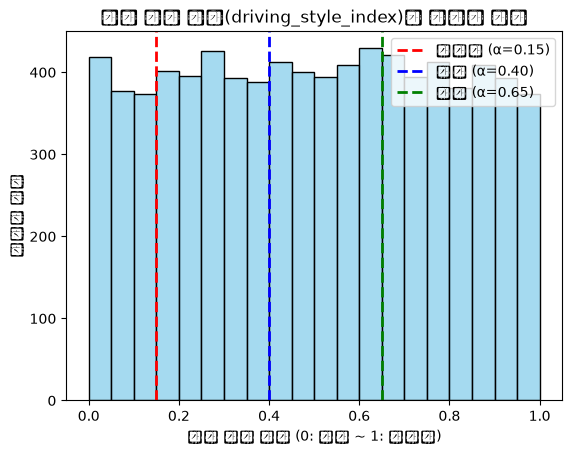

In [23]:
# 1. 운전 성향 지수 기본 히스토그램
sb.histplot(df['driving_style_index'], bins=20, color='skyblue', edgecolor='black')

# 2. 모드별 알파(α) 기준선 추가
plt.axvline(0.15, color='red', linestyle='--', linewidth=2, label='스포츠 (α=0.15)')
plt.axvline(0.40, color='blue', linestyle='--', linewidth=2, label='일반 (α=0.40)')
plt.axvline(0.65, color='green', linestyle='--', linewidth=2, label='에코 (α=0.65)')

# 3. 제목 및 범례 설정
plt.title('운전 성향 지수(driving_style_index)와 알파값 기준')
plt.xlabel('운전 성향 지수 (0: 정속 ~ 1: 급가속)')
plt.ylabel('데이터 개수')
plt.legend()
plt.show()

#### 최적 속도 구하는 함수 

In [34]:
def recommend_optimal_cruising_speed(model, env_conditions: dict, trip_distance: float, alpha: float):
    """
    model: 학습된 RandomForestRegressor 모델 (rf_reg)
    env_conditions: 속도와 거리를 제외한 7개 주행 환경 딕셔너리
    trip_distance: 목적지까지 남은 거리 (km)
    alpha: 에너지 소모 가중치 (에코 0.65, 일반 0.40, 스포츠 0.15)
    """
    # 1. 20km/h ~ 130km/h 후보 속도군 생성 (1km/h 단위)
    candidate_speeds = np.arange(20, 131, 1)
    
    # 2. 가상 주행 데이터프레임 구성 (X_train 피처 순서와 일치)
    sim_data = []
    for s in candidate_speeds:
        row = env_conditions.copy()
        row['speed_kmh'] = s
        row['trip_distance_km'] = trip_distance
        sim_data.append(row)
        
    sim_df = pd.DataFrame(sim_data)[X_train.columns]
    
    # 3. RandomForest 모델로 100km당 전비 예측 및 총 소비량/주행시간 산출
    pred_energy_100k = rf_reg.predict(sim_df)
    total_energy_kwh = pred_energy_100k * (trip_distance / 100.0)
    travel_time_hours = trip_distance / candidate_speeds
    
    # 4. 0 ~ 1 Min-Max 정규화
    norm_energy = (total_energy_kwh - total_energy_kwh.min()) / (total_energy_kwh.max() - total_energy_kwh.min() + 1e-8)
    norm_time = (travel_time_hours - travel_time_hours.min()) / (travel_time_hours.max() - travel_time_hours.min() + 1e-8)
    
    # 5. 가중 목적함수 (Cost) 계산 및 최소 비용 속도 탐색
    cost_curve = alpha * norm_energy + (1.0 - alpha) * norm_time
    opt_idx = np.argmin(cost_curve)
    
    return {
        'alpha': alpha,
        'best_speed': candidate_speeds[opt_idx],
        'pred_100k': pred_energy_100k[opt_idx],
        'total_energy': total_energy_kwh[opt_idx],
        'travel_time_h': travel_time_hours[opt_idx],
        'speeds': candidate_speeds,
        'cost_curve': cost_curve
    }

In [37]:
# 7개 환경 변수를 딕셔너리로 묶음
env_conditions = {
    'road_grade_pct': 3.0,
    'payload_kg': 100.0,
    'ambient_temp_C': 25.0,
    'hvac_power_kw': 1.5,
    'battery_temp_C': 30.0,
    'driving_style_index': 0.3,
    'tire_pressure_bar': 2.4
}

# 함수 호출
res = recommend_optimal_cruising_speed(
    model=xgb_reg,
    env_conditions=env_conditions,
    trip_distance=80.0,
    alpha=0.4
)

In [38]:
# 2. 결과 깔끔하게 출력
print("=== [최적 순항 속도 추천 결과] ===")
print(f"추천 최적 속도   : {res['best_speed']} km/h")
print(f"예상 100km 전비  : {res['pred_100k']:.2f} kWh/100km")
print(f"총 예상 전력 소모: {res['total_energy']:.2f} kWh")
print(f"예상 소요 시간   : {res['travel_time_h']:.2f} 시간 ({res['travel_time_h'] * 60:.1f} 분)")
print(f"최종 손실 비용   : {res['cost_curve'].min():.4f}")

=== [최적 순항 속도 추천 결과] ===
추천 최적 속도   : 63 km/h
예상 100km 전비  : 20.34 kWh/100km
총 예상 전력 소모: 16.27 kWh
예상 소요 시간   : 1.27 시간 (76.2 분)
최종 손실 비용   : 0.2274
